# BREADTH FIRST SEARCH AND DEPTH FIRST SEARCH

I will build a Node class to handle the graph structure.
Since BFS explores the breadth of the graph, meaning it visits all neighbours of the current n0de before moving to the next level.

I will use a queue to keep track of which nodes to visit next in the correct.

DFS on the other hand explores deep first using, so I will use a stack.

**Creating the node**

In [11]:
class Node:
    def __init__(self, name):
        self.name = name
        self.neighbors = []

    def add_neighbor(self, neighbor_node):
        self.neighbors.append(neighbor_node)

**Create a Tree**


In [12]:
root = Node("A")
b = Node("B")
c = Node("C")
d = Node("D")
e = Node("E")
f = Node("F")

root.add_neighbor(b)
root.add_neighbor(c)


b.add_neighbor(d)
b.add_neighbor(e)


c.add_neighbor(f)

**Lets visualize the Tree**

Using ```networkx``` and ```matplotlib``` libraries.

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

def hierarchy_pos(G, root, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5):
    """Calculates coordinates for a tree layout (Root at top)."""
    pos = {root: (xcenter, vert_loc)}
    def _hierarchy_pos(G, root, width, vert_gap, vert_loc, xcenter, pos, parent=None):
        neighbors = list(G.neighbors(root))
        if len(neighbors) != 0:
            dx = width / len(neighbors) 
            nextx = xcenter - width/2 - dx/2
            for neighbor in neighbors:
                nextx += dx
                pos[neighbor] = (nextx, vert_loc - vert_gap)
                _hierarchy_pos(G, neighbor, dx, vert_gap, vert_loc - vert_gap, nextx, pos, parent=root)
        return pos
    return _hierarchy_pos(G, root, width, vert_gap, vert_loc, xcenter, pos)

def visualize_tree(root_node):
    G = nx.DiGraph()
    def build_nx(node):
        for n in node.neighbors:
            G.add_edge(node.name, n.name)
            build_nx(n)

    build_nx(root)
    pos = hierarchy_pos(G, 'A') # Set 'A' as top node

    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color="#90EE90", 
            font_size=12, font_weight="bold", arrows=True)
    plt.title("Tree Structure (Root at Top)")
    plt.show()

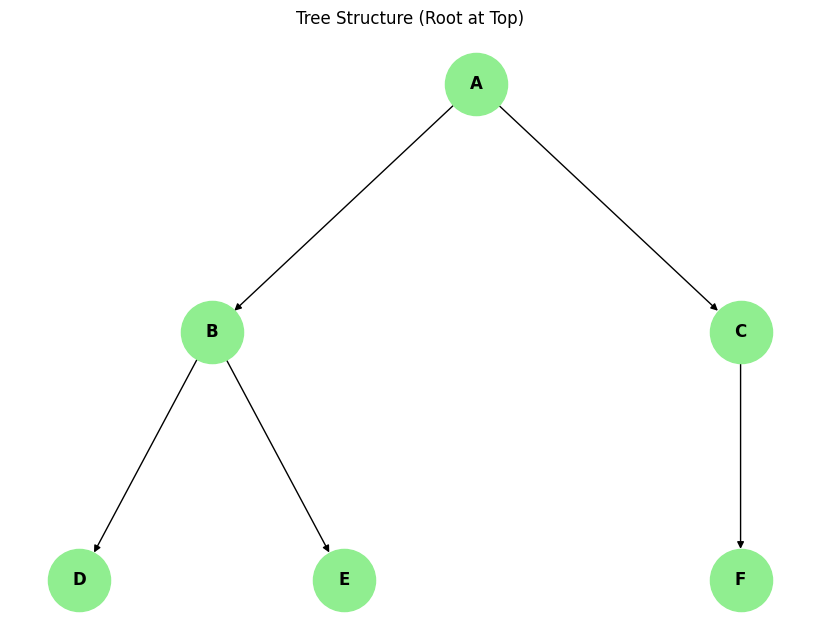

In [17]:
visualize_tree(root)

# The search algorithms

I will create them using the ```python-collections lib```

**Breadth First Search**

In [19]:
from collections import deque

def bfs_path(start_node, goal_name):
    """Uses a Queue"""
    queue = deque([(start_node, [start_node.name])])
    visited = set()

    while queue:
        (node, path) = queue.popleft()
        if node.name not in visited:
            if node.name == goal_name:
                return path
            visited.add(node.name)
            for neighbor in node.neighbors:
                queue.append((neighbor, path + [neighbor.name]))

    return None

**Depth first Search**

In [21]:
def dfs_path(start_node, goal_name):
    """Depth-First Search: Explores deep first using a Stack."""
    stack = [(start_node, [start_node.name])]
    visited = set()

    while stack:
        (node, path) = stack.pop()
        if node.name not in visited:
            if node.name == goal_name:
                return path
            visited.add(node.name)
            # Reversing neighbors keeps the exploration left-to-right
            for neighbor in reversed(node.neighbors):
                stack.append((neighbor, path + [neighbor.name]))
    return None

**Testing the algos**

In [ ]:
goal = "F"

BFS


In [ ]:
print(f"BFS Path to {goal}: {bfs_path(root, goal)}")